**Aulas 11 - Clusterização**

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

O projeto requer Python 3.7 ou acima:

In [ ]:
import sys

assert sys.version_info >= (3, 7)

Também requer Scikit-Learn ≥ 1.0.1:

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Definindo as fontes dos gráficos, apenas para estética:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Define a função `save_fig()`, que gravará as imagens geradas para os gráficos na pasta `images/clustering`. Assim todas as imagens plotadas abaixo, ficam disponíveis para download.

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "clustering"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Clusterização (Clustering)

**Introdução – Classificacação *vs* Clusterização**

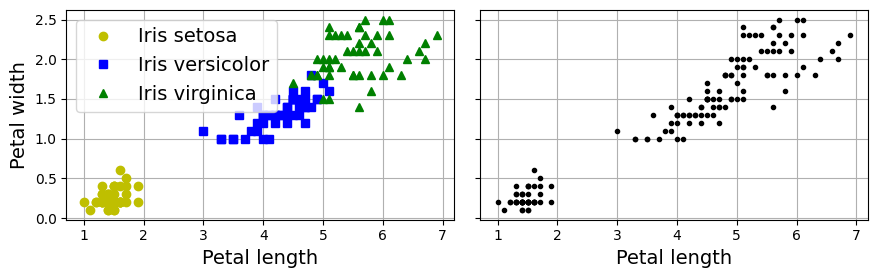

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target
data.target_names

plt.figure(figsize=(9, 3))

plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()

save_fig("classification_vs_clustering_plot")
plt.show()

**Observação**: A próxima célula mostra como um modelo de mistura Gaussiana pode, na prática, separar esses clusters muito bem utilizando todas as 4 características: comprimento e largura da pétala, e comprimento e largura da sépala. Este código mapeia cada cluster para uma classe. Em vez de definir o mapeamento manualmente, o código seleciona a classe mais frequente para cada cluster utilizando a função `scipy.stats.mode()`

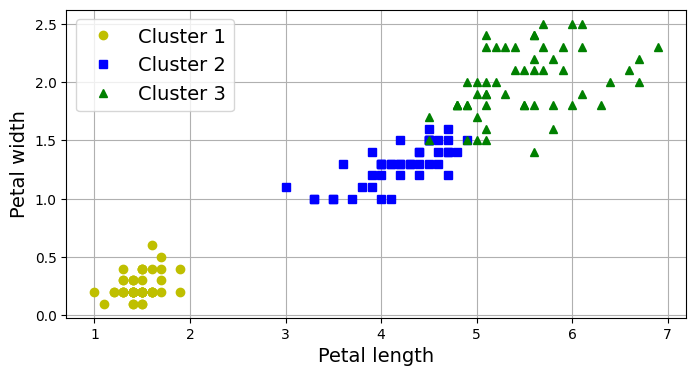

In [ ]:
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture

y_pred = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)

mapping = {}
for class_id in np.unique(y):
    mode, _ = stats.mode(y_pred[y==class_id])
    mapping[mode] = class_id

y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])

plt.figure(figsize=(8, 4))
plt.plot(X[y_pred==0, 2], X[y_pred==0, 3], "yo", label="Cluster 1")
plt.plot(X[y_pred==1, 2], X[y_pred==1, 3], "bs", label="Cluster 2")
plt.plot(X[y_pred==2, 2], X[y_pred==2, 3], "g^", label="Cluster 3")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.grid()
plt.show()

Qual é a proporção de Plantas Íris atribuidas ao cluster correto?

In [ ]:
(y_pred==y).sum() / len(y_pred)

np.float64(0.9666666666666667)

# FIM DA 1ª DA DEMONSTRAÇÃO - voltar aos slides

# K-Means

## Treinar e Prever

Vamos treinar um clusterizador K-Means em um conjunto de dados de blobs. Ele tentará encontrar o centro de cada blob e atribuir cada instância ao blob mais próximo

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Os valores exatos de argumentos para make_blobs() não é importante
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  2.0],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,
                  random_state=7)

k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

Observação: ao longo deste notebook, quando `n_init` não foi definido ao criar um estimador `KMeans`, está definido explicitamente como `n_init=10` para evitar um aviso sobre o fato de que o valor padrão desse hiperparâmetro mudará de 10 para `"auto"` no Scikit-Learn 1.4.

Agora vamos exibir os dados graficamente

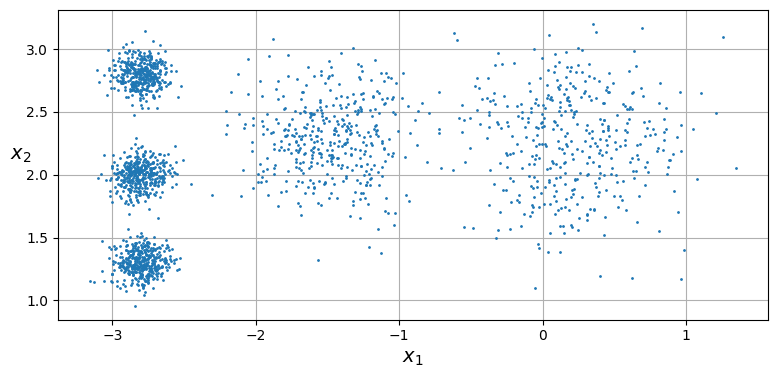

In [ ]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()
save_fig("blobs_plot")
plt.show()

Cada instância é atribuia a um dos 5 Clusters

In [ ]:
y_pred

array([1, 4, 0, ..., 2, 0, 4], dtype=int32)

In [ ]:
y_pred is kmeans.labels_

True

E os seguintes 5 _centroides_ (ou seja, centros dos clusters) foram estimados

In [ ]:
kmeans.cluster_centers_

array([[ 0.20876306,  2.25551336],
       [-2.80052143,  1.30046968],
       [-2.79290307,  2.79641063],
       [-1.46492897,  2.28575851],
       [-2.80225995,  1.99960541]])

Observe que a instância de `KMeans` preserva os rótulos das instâncias nas quais foi treinada na propriedade `labels_`. De forma um tanto confusa, neste contexto, o *rótulo* de uma instância é o índice do cluster ao qual essa instância é atribuída (não são alvos, são previsões)

In [ ]:
kmeans.labels_

array([1, 4, 0, ..., 2, 0, 4], dtype=int32)

Claro, podemos prever rótulos para novas instâncias

In [ ]:
import numpy as np

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 0, 2, 2], dtype=int32)

**Fronteiras de Decisão**

Vamos plotar as fronteiras de decisão do modelo. Isso nos fornece o *Diagrama de Voronoi*

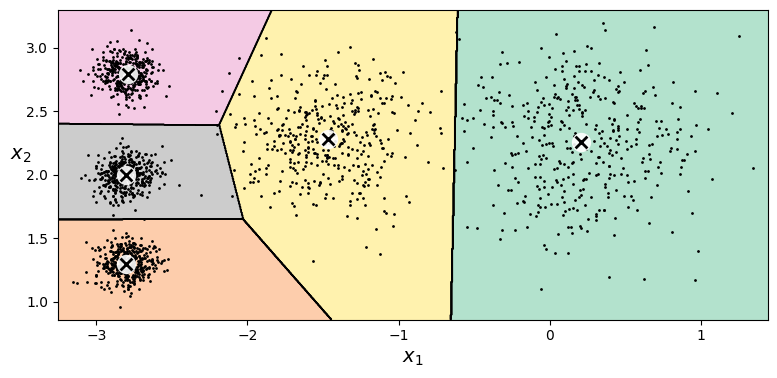

In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
save_fig("voronoi_plot")
plt.show()

Nada mal! Algumas das instâncias próximas às bordas provavelmente foram atribuídas ao cluster errado, mas, no geral, o resultado parece bastante bom.

## O Algoritmo K-Means

O algoritmo K-Means é um dos algoritmos de clusterização mais rápidos, além de ser um dos mais simples
* Primeiro, inicialize $k$ centroides aleatoriamente: por exemplo, $k$ instâncias distintas são escolhidas aleatoriamente do conjunto de dados, e os centroides são posicionados em suas localizações.
* Repita até a convergência (ou seja, até que os centroides parem de se mover):
    * Atribua cada instância ao centroide mais próximo.
    * Atualize os centroides para que sejam a média das instâncias que foram atribuídas a eles.

A classe `KMeans` utiliza, por padrão, uma técnica de inicialização otimizada. Para obter o algoritmo K-Means original (apenas para fins educacionais), você deve definir `init="random"` e `n_init=1`.

Vamos executar o algoritmo K-Means por 1, 2 e 3 iterações, para observar como os centroides se deslocam

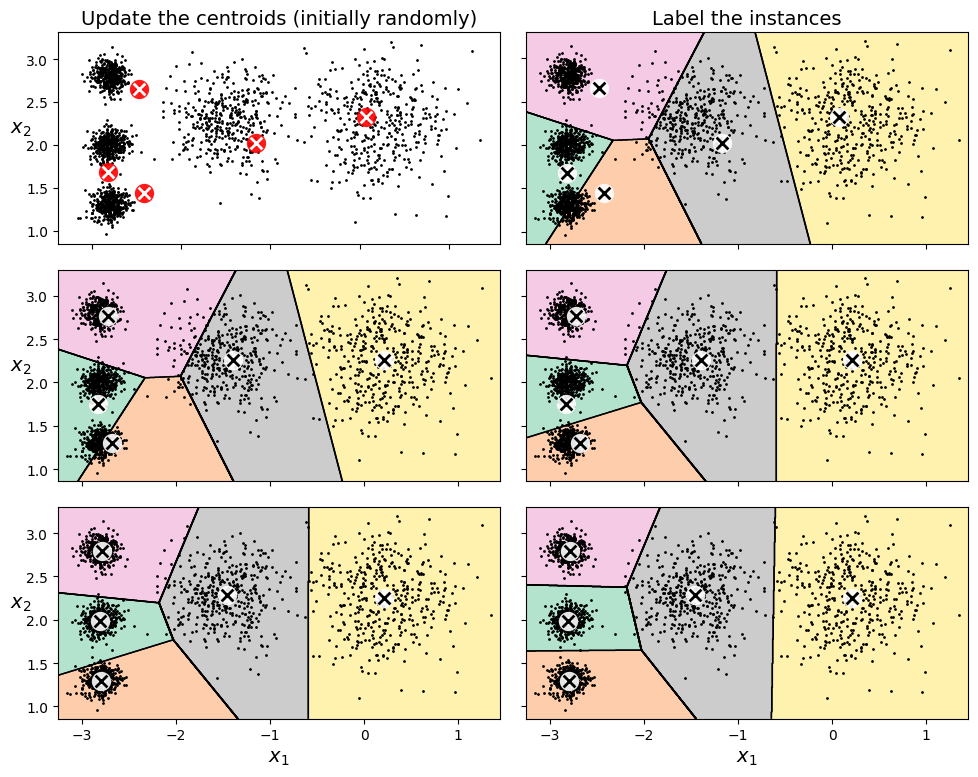

In [ ]:
kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=1,
                      random_state=20)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=2,
                      random_state=20)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=3,
                      random_state=20)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)")

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False,
                         show_ylabels=False)
plt.title("Label the instances")

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False,
                         show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False,
                         show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

save_fig("kmeans_algorithm_plot")
plt.show()

**Variabilidade do K-Means**

No algoritmo K-Means original, os centroides são inicializados de forma totalmente aleatória, e o algoritmo simplesmente executa uma única execução (com várias iterações internas) para gradualmente melhorar os centroides, como vimos acima.

No entanto, um grande problema dessa abordagem é que, se você executar o K-Means várias vezes (ou com diferentes sementes aleatórias), ele pode convergir para soluções bastante diferentes, como você pode observar abaixo.

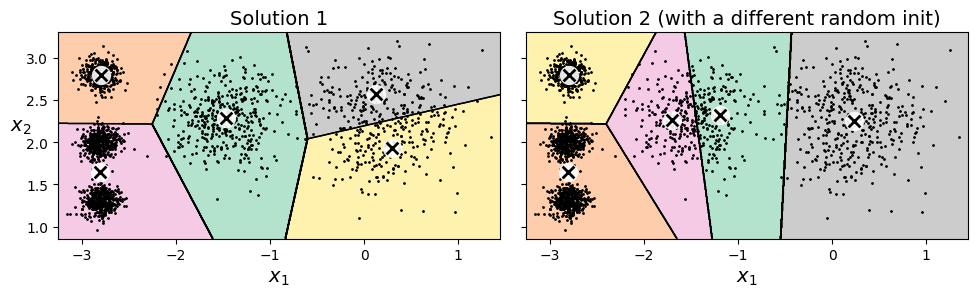

In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None,
                              title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2)

kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1, random_state=2)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=1, random_state=15)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1",
                          "Solution 2 (with a different random init)")

save_fig("kmeans_variability_plot")
plt.show()

Para evitar este problema, é possível indicar uma posição aproximada dos centros dos centroides para o algoritmo, através do `init_good`.

In [ ]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

KMeans(init=array([[-3,  3],
       [-3,  2],
       [-3,  1],
       [-1,  2],
       [ 0,  2]]),
       n_clusters=5, n_init=1, random_state=42)

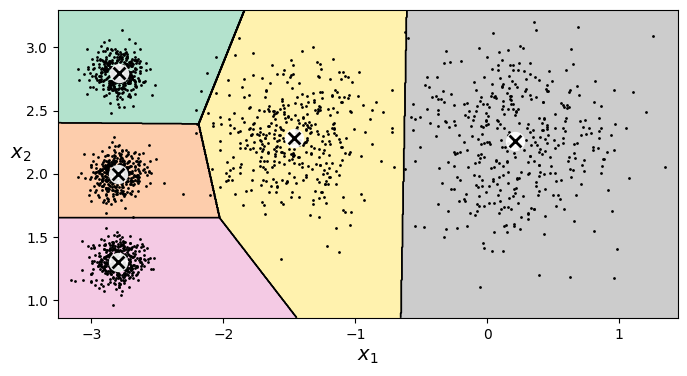

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)

## Inércia

Para selecionar o melhor modelo, precisaremos de uma forma de avaliar o desempenho de um modelo K-Means. Infelizmente, a clusterização é uma tarefa não supervisionada, portanto não temos os rótulos (targets). Mas, pelo menos, podemos medir a distância entre cada instância e o seu centroide. Essa é a ideia por trás da métrica de _inércia_.

In [ ]:
kmeans.inertia_

211.77405556488773

In [ ]:
kmeans_rnd_init1.inertia_

267.16545836020896

In [ ]:
kmeans_rnd_init2.inertia_

284.5825932781008

## Múltiplas Inicializações

Uma abordagem para resolver o problema da variabilidade é simplesmente executar o algoritmo K-Means várias vezes com diferentes inicializações aleatórias e selecionar a solução que minimize a inércia.

Quando você define o hiperparâmetro `n_init`, o Scikit-Learn executa o algoritmo original `n_init` vezes e seleciona a solução que minimiza a inércia. Por padrão, o Scikit-Learn define `n_init=10`.

In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                             random_state=2)
kmeans_rnd_10_inits.fit(X)

KMeans(init='random', n_clusters=5, n_init=10, random_state=2)

Aqui obtemos o modelo inicial, que certamente é a solução ótima do K-Means (pelo menos em termos de inércia, assumindo $k=5$).

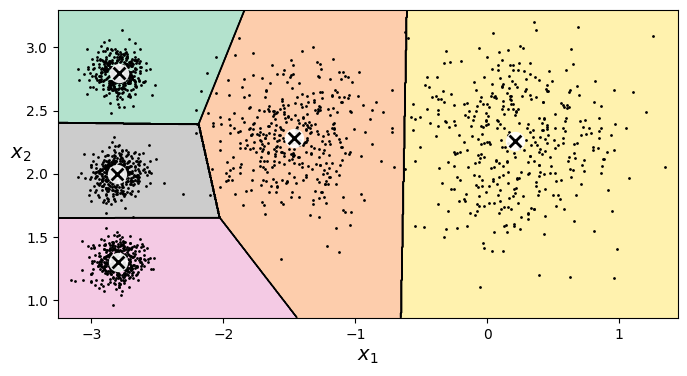

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

In [ ]:
kmeans_rnd_10_inits.inertia_

211.77163376327533

### Métodos de inicialização de Centroides (EXTRA)

Em vez de inicializar os centroides totalmente de forma aleatória, é preferível inicializá-los utilizando o seguinte algoritmo, proposto em um [artigo de 2006](https://goo.gl/eNUPw6) por David Arthur e Sergei Vassilvitskii:
* Escolha um centroide $c_1$, selecionado uniformemente ao acaso a partir do conjunto de dados.
* Escolha um novo centro $c_i$, selecionando uma instância $\mathbf{x}_i$ com probabilidade: $D(\mathbf{x}_i)^2$ / $\sum\limits_{j=1}^{m}{D(\mathbf{x}_j)}^2$, onde $D(\mathbf{x}_i)$ é a distância entre a instância $\mathbf{x}_i$ e o centroide mais próximo que já foi escolhido. Essa distribuição de probabilidade garante que instâncias mais distantes dos centroides já selecionados tenham muito mais chance de serem escolhidas como novos centroides.
* Repita o passo anterior até que todos os $k$ centroides tenham sido escolhidos.

O restante do algoritmo K-Means++ é simplesmente o K-Means tradicional. Com esta inicialização, o algoritmo K-Means probabilidade muito menor de convergir para uma solução não otimizada, de modo que é possível reduzir consideravelmente o valor de `n_init`. Na maioria das vezes, isso compensa muito a complexidade adicional do processo de inicialização.

Para definir de forma forçada a inicialização como K-Means++, basta configurar `init="k-means++"`, porém, este já é o valor padrão.

#### K-Means Acelerados

O algoritmo K-Means pode, às vezes, ser acelerado evitando muitos cálculos desnecessários de distância. Isso é obtido explorando a desigualdade triangular (dados três pontos A, B e C, a distância AC é sempre tal que AC ≤ AB + BC) e mantendo limites inferiores e superiores para as distâncias entre instâncias e centroides (veja este [artigo de 2003](https://www.aaai.org/Papers/ICML/2003/ICML03-022.pdf) de Charles Elkan para mais detalhes).

Para utilizar a variante do algoritmo de K-Means de Elkan, utilize `algorithm="elkan"`. Para o KMeans padrão, utilize `algorithm="full"`. O valor padrão é `"auto"`, que utiliza o algoritmo completo desde o Scikit-Learn 1.1 (antes disso, utilizava o algoritmo de Elkan).

#### K-Means em Mini-Batch

O Scikit-Learn também implementa uma variante do algoritmo K-Means que suporta mini-batches (veja [este artigo](http://www.eecs.tufts.edu/~dsculley/papers/fastkmeans.pdf)).

In [ ]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, n_init=3, random_state=42)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5, n_init=3, random_state=42)

**Observação** - Ao longo deste notebook, quando `n_init` não foi definido ao criar um estimador `MiniBatchKMeans`, está definido explicitamente como `n_init=3` para evitar um aviso sobre o fato de que o valor padrão desse hiperparâmetro mudará de 3 para `"auto"` no Scikit-Learn 1.4.

In [ ]:
minibatch_kmeans.inertia_

211.82781009622295

## FIM DA 2ª DA DEMONSTRAÇÃO - voltar aos slides

## Encontrando o número ideal de Clusters

E se o número de clusters fosse definido como um valor menor ou maior do que 5?

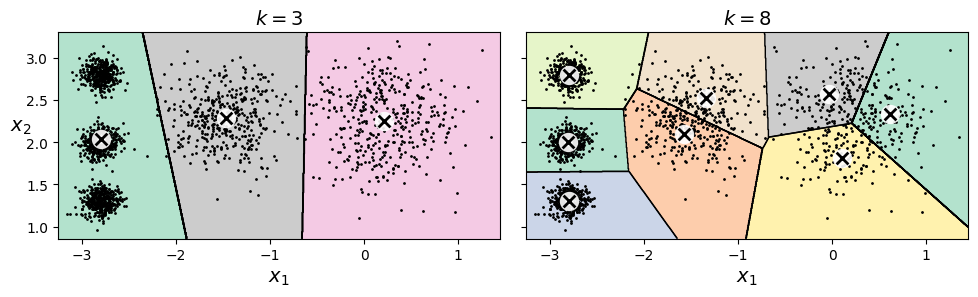

In [ ]:
kmeans_k3 = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_k8 = KMeans(n_clusters=8, n_init=10, random_state=42)

plot_clusterer_comparison(kmeans_k3, kmeans_k8, X, "$k=3$", "$k=8$")
save_fig("bad_n_clusters_plot")
plt.show()

Esses dois modelos não parecem muito bons. E como ficam suas Inércias?

In [ ]:
kmeans_k3.inertia_

661.2705329153574

In [ ]:
kmeans_k8.inertia_

118.59635889409081

Não podemos simplesmente escolher o valor de $k$ que minimiza a inércia, pois ela continua diminuindo à medida que aumentamos $k$.

De fato, quanto mais clusters houver, mais próxima cada instância estará de seu centroide mais próximo e, consequentemente, menor será a inércia.

Porém, podemos plotar a inércia como uma função de $k$ e analisar a curva resultante.

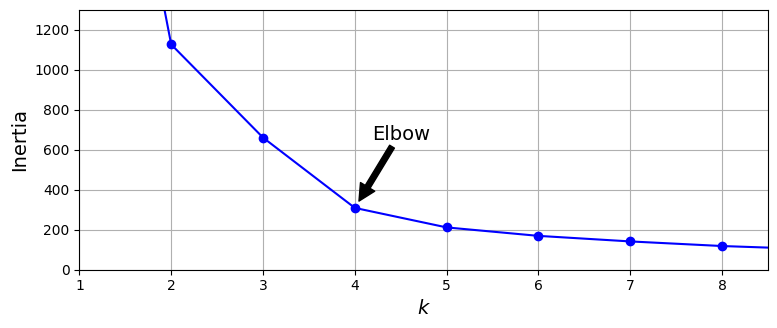

In [ ]:
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1300])
plt.grid()
save_fig("inertia_vs_k_plot")
plt.show()

Como você pode ver, há um “cotovelo” em $k=4$, o que significa que menos clusters do que isso seria inadequado, e mais clusters não ajudariam muito e poderiam até dividir clusters ao meio.

Desta forma, $k=4$ é uma escolha bastante razoável. Claro que, neste exemplo, não é perfeito, pois isso implica que os dois blobs no canto inferior esquerdo serão considerados como um único cluster, mas ainda assim é uma clusterização bastante satisfatória.

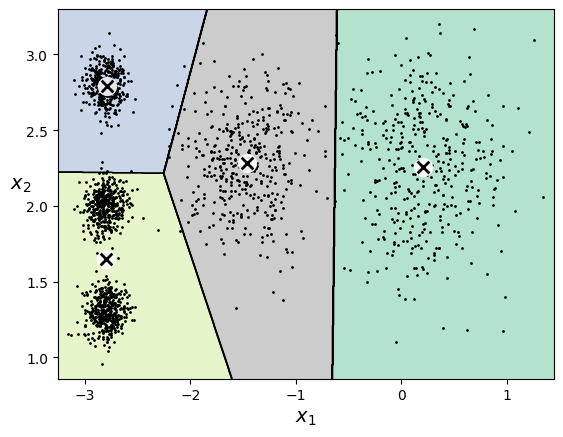

In [ ]:
plot_decision_boundaries(kmeans_per_k[4 - 1], X)
plt.show()

Outra abordagem é analisar o *Silhouette Score*, que é a média do *coeficiente de Silhouette* de todas as instâncias.

O *coeficiente de Silhouette* de uma instância é igual a (_b_ - _a_) / max(_a_, _b_), onde _a_ é a distância média até as outras instâncias do mesmo cluster (ou seja, a _distância média intra-cluster_), e _b_ é a _distância média até o cluster mais próximo_, isto é, a distância média até as instâncias do cluster mais próximo (definido como aquele que minimiza _b_, excluindo o próprio cluster da instância).

O *coeficiente de Silhouette* pode variar entre -1 e +1: um valor próximo de +1 indica que a instância está bem dentro do seu próprio cluster e distante dos demais; um valor próximo de 0 indica que ela está próxima da fronteira entre clusters; e um valor próximo de -1 indica que a instância pode ter sido atribuída ao cluster errado.

Vamos plotar o _Silhouette Score_ como uma função de $k$

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_score(X, kmeans.labels_)

np.float64(0.6817720742209897)

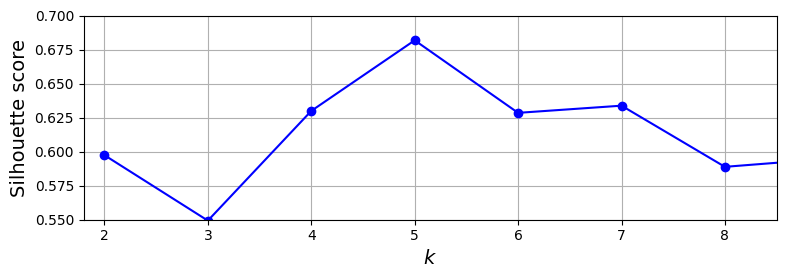

In [ ]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
save_fig("silhouette_score_vs_k_plot")
plt.show()

Essa visualização é muito mais rica do que a anterior: em particular, embora indique que $k=4$ é uma escolha muito boa, ela também destaca que $k=5$ é uma opção mais adequada. E também indique que $k=6$ ou $k=7$, seriam escolhas razoáveis e com resultado bem similar a $k=4$.

Uma visualização ainda mais informativa é obtida quando você plota o *coeficiente de Silhouette* de cada instância, ordenado pelo cluster ao qual ela foi atribuída e pelo valor do coeficiente. Isso é chamado de *Diagrama de Silhouette*:

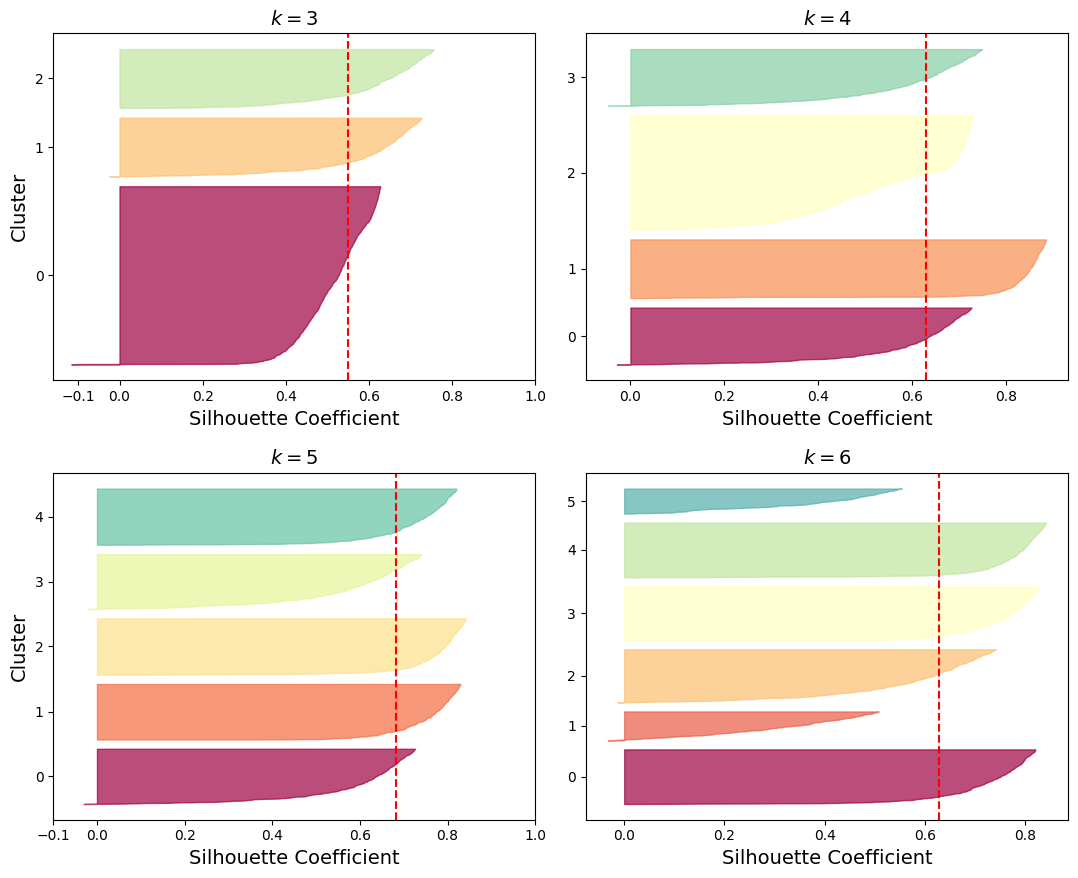

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.xlabel("Silhouette Coefficient")

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")

save_fig("silhouette_analysis_plot")
plt.show()

Como você pode ver, $k=5$ parece ser a melhor opção aqui, pois todos os clusters têm aproximadamente o mesmo tamanho e todos cruzam a linha tracejada, que representa a média do *silhouette score*.

## Limitaçõess do K-Means

Vamos gerar um conjunto de dados mais desafiador, com blobs alongados e densidades variadas, e mostrar que o K-Means tem dificuldade para agrupá-lo corretamente

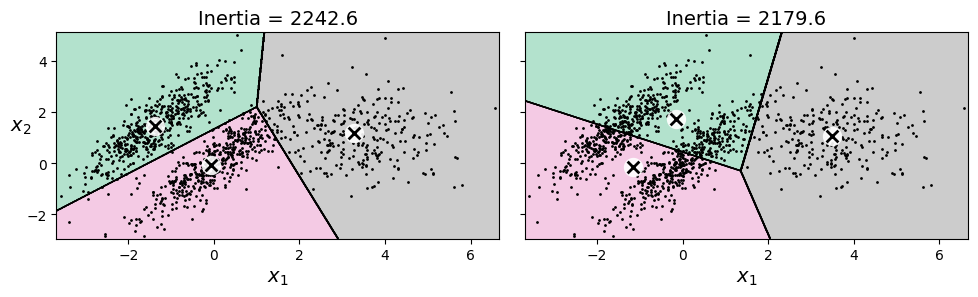

In [ ]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

kmeans_good = KMeans(n_clusters=3,
                     init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]),
                     n_init=1, random_state=42)
kmeans_bad = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_good.fit(X)
kmeans_bad.fit(X)

plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title(f"Inertia = {kmeans_good.inertia_:.1f}")

plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title(f"Inertia = {kmeans_bad.inertia_:.1f}")

save_fig("bad_kmeans_plot")
plt.show()

## FIM DA 3ª DA DEMONSTRAÇÃO - voltar aos slides

## EXTRAS → Exemplos de Aplicações Práticas

### Usando Clusterização para Segmentação de Imagens

Download da imagem da Joaninha

In [ ]:
import urllib.request

homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
filename = "ladybug.png"
filepath = IMAGES_PATH / filename
if not filepath.is_file():
    print("Downloading", filename)
    url = f"{homl3_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

In [ ]:
import PIL

image = np.asarray(PIL.Image.open(filepath))
image.shape

(533, 800, 3)

In [ ]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

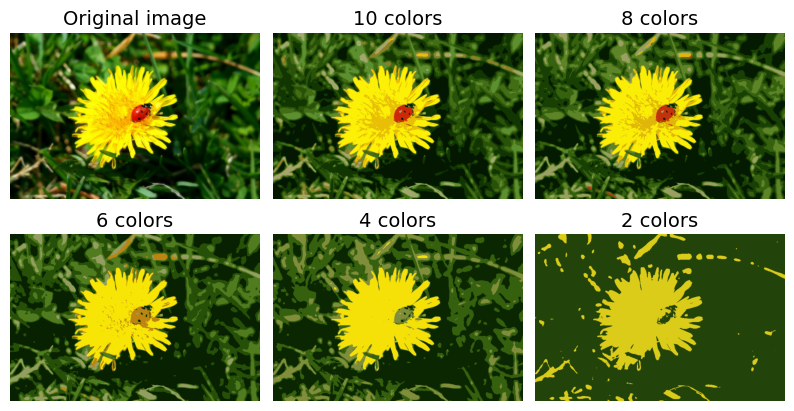

In [ ]:
segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

save_fig('image_segmentation_plot', tight_layout=False)
plt.show()

### Usando Clusterização para Aprendizado Semi Supervisionado

Outro caso de uso para clusterização é o aprendizado semi-supervisionado, quando temos muitas instâncias não rotuladas e muito poucas instâncias rotuladas.

Vamos trabalhar com o _digits dataset_, que é um conjunto de dados simples, semelhante ao MNIST, contendo 1.797 imagens em tons de cinza de 8×8 pixels representando dígitos de 0 a 9.

In [ ]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

Vamos analisar o desempenho de um modelo de regressão logística quando temos apenas 50 instâncias rotuladas

In [ ]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

LogisticRegression(max_iter=10000)

In [ ]:
log_reg.score(X_test, y_test)

0.7581863979848866

Medindo a acurácia quando utilizamos todo o conjunto de treinamento

In [ ]:
log_reg_full = LogisticRegression(max_iter=10_000)
log_reg_full.fit(X_train, y_train)
log_reg_full.score(X_test, y_test)

0.9093198992443325

A acurácia somente com 50 instâncias, fica bem menor do que com o conjunto completo. Vamos ver como podemos melhorar isso.

Primeiro, vamos agrupar o conjunto de treinamento em 50 clusters; em seguida, para cada cluster, vamos encontrar a imagem mais próxima do centroide. Chamaremos essas imagens de imagens representativas.

In [ ]:
k = 50
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = X_digits_dist.argmin(axis=0)
X_representative_digits = X_train[representative_digit_idx]

Agora vamos plotar essas imagens representativas e rotulá-las manualmente.

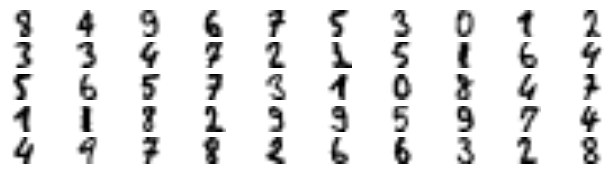

In [ ]:
plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

save_fig("representative_images_plot", tight_layout=False)
plt.show()

In [ ]:
y_representative_digits = np.array([
     8, 4, 9, 6, 7, 5, 3, 0, 1, 2,
     3, 3, 4, 7, 2, 1, 5, 1, 6, 4,
     5, 6, 5, 7, 3, 1, 0, 8, 4, 7,
     1, 1, 8, 2, 9, 9, 5, 9, 7, 4,
     4, 9, 7, 8, 2, 6, 6, 3, 2, 8
])

Agora temos um conjunto de dados com apenas 50 instâncias rotuladas, mas, em vez de serem instâncias completamente aleatórias, cada uma delas é uma imagem representativa do seu cluster. Vamos ver se o desempenho melhora.

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8387909319899244

Olha só, saltamos de 74,8% de acurácia para 83,8%, embora ainda estejamos treinando o modelo com apenas 50 instâncias. Como rotular dados costuma ser caro e trabalhoso, especialmente quando precisa ser feito manualmente por especialistas, é uma boa ideia priorizar a rotulação de instâncias representativas em vez de escolher instâncias aleatórias.

Mas talvez possamos ir um passo além. E se propagarmos os rótulos para todas as outras instâncias do mesmo cluster?

In [ ]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train, y_train_propagated)

LogisticRegression(max_iter=10000)

In [ ]:
log_reg.score(X_test, y_test)

0.8589420654911839

Obtivemos outro aumento significativo na acurácia! Vamos ver se conseguimos melhorar ainda mais selecionando somente 40% das instâncias que estão mais próximas do centro do seu cluster: isso deve eliminar muitos outliers.

In [ ]:
percentile_closest = 40

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8740554156171285

Outra melhora na acurácia! Só que com um treinamento com um conjunto menor de dados, portanto, muito mais rápido.

## DBSCAN

Criação de um Dataset utilizando o `make_moons`, com 1000 amostras.

Na sequencia, treina um DBSCAN com `eps=0.05` e `min_samples=5`.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

Na propriedade `labels_`, é possível consultar o cluster ao qual cada instância foi atribuida.

As instâncias que ficaram com label -1, são as instâncias consideradas anomalias pelo algoritmo, e por isso, não se encaixam em nenhum cluster.

In [ ]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5])

As amostras que fazem parte de um cluster, tem seu índice listado em `core_sample_indices`

In [ ]:
dbscan.core_sample_indices_[:10]

array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13])

Em `componentes_`, temos os dados das amostras que compôem os cores.

Se utilizar os índices em `core_sample_indices_` e procurar em `X`, será possível observar que são exatamente os mesmos dados, mas em `components_` não há as informações das instâncias de `X` que não se enquadraram em nenhum Cluster.

In [ ]:
dbscan.components_[:10]

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       [ 0.29248724, -0.20696309],
       [-0.02637836,  0.44766267],
       [ 1.6201408 , -0.28758856],
       [ 1.26718285, -0.40793471],
       [ 0.87418608,  0.50781041],
       [ 0.3322007 , -0.19032202],
       [ 1.952812  ,  0.22552333]])

In [ ]:
X[:10]

array([[-0.02137124,  0.40618608],
       [ 0.97670045, -0.45832306],
       [ 0.90405882, -0.37651952],
       [ 0.37736316, -0.39703717],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       [ 0.29248724, -0.20696309],
       [-0.02637836,  0.44766267],
       [ 1.6201408 , -0.28758856],
       [ 0.68246733,  0.80712069]])

Visualizando os dados dos do Modelo Treinado e seus respectivos Clusters, assim como as instâncias identificadas como Anomalias (X vermelho).

In [ ]:
#Função para criar a visualização gráfica do DBSCAN
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

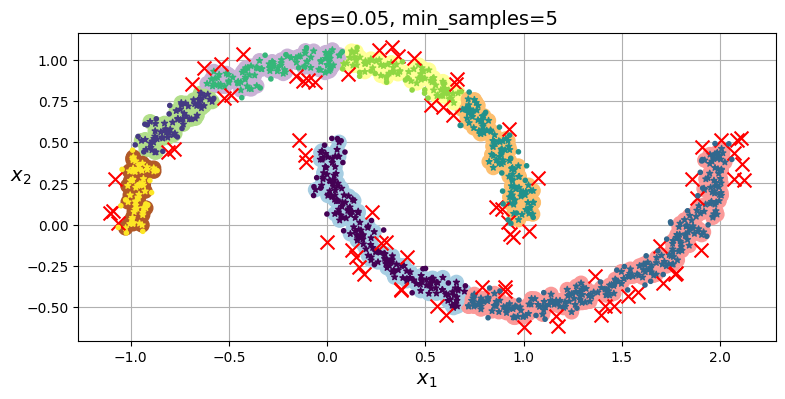

In [ ]:
plt.figure(figsize=(9, 4))

#plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

Como foram identificados vários clusters diferentes e muitas anomalias, aqui é treinado um novo DBSCAN, agora com `eps=0.2`.

In [ ]:
dbscan2 = DBSCAN(eps=0.2, min_samples=5)
dbscan2.fit(X)

DBSCAN(eps=0.2)

Agora vamos comparar os dois modelos.

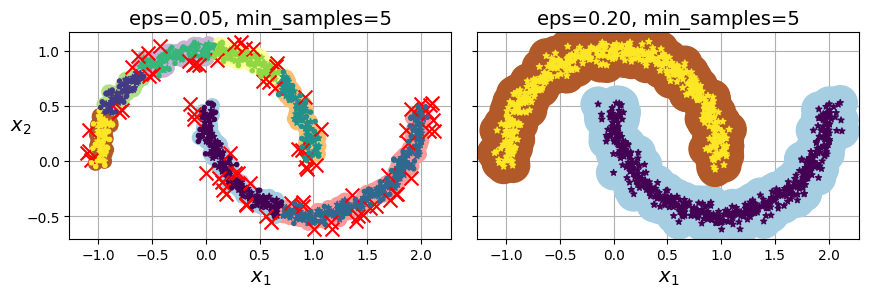

In [ ]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

save_fig("dbscan_plot")
plt.show()

Daqui em diante, passaremos a utilizar somente o dbscan calculado com `eps=0.20` e `min_samples=5`, pois claramente, teve um resultado superior.

In [ ]:
dbscan = dbscan2  # extra code – the text says we now use eps=0.2

Também é possível utilizar os dados do DBSCAN para treinar um Classificador, com base nos Clusters identificado. Para isso, é utilizada a classe `KNeighborsClassifier`.

Aqui treinaremos um novo Classificador, onde o parâmetro `n_neighbors=50`define que, sempre que informado um novo ponto, serão considerados os 50 vizinhos mais próximos para classificar um novo ponto.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

Aqui, introduzimos novas instâncias, e depois, utilizando o `predict`, vamos fazer a classificação dos clusteres aos quais cada nova instância pertence.

In [ ]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

Assim como em outros modelos Classificadores, também é possível identificar a probabilidade de cada classe, através do `predict_proba`.

In [ ]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

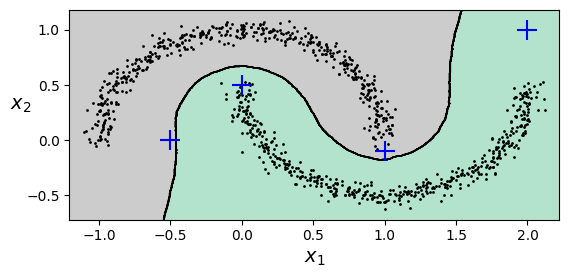

In [ ]:
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
save_fig("cluster_classification_plot")
plt.show()

## FIM DA 4ª DA DEMONSTRAÇÃO - voltar aos slides

# Exercícios

### 1.
O clássico conjunto de dados Olivetti Faces contém 400 imagens em tons de cinza de rostos, com 64 × 64 pixels. Cada imagem é transformada (flatten) em um vetor unidimensional de tamanho 4.096. Foram fotografadas 40 pessoas diferentes (10 vezes cada), e a tarefa usual é treinar um modelo capaz de prever qual pessoa está representada em cada imagem.

Carregue o conjunto de dados utilizando a função sklearn.datasets.fetch_olivetti_faces().

Divida o conjunto em um conjunto de treinamento, um conjunto de validação e um conjunto de teste (observe que o conjunto de dados já está escalado entre 0 e 1).

Como o conjunto de dados é relativamente pequeno, use uma amostragem estratificada para garantir que haja o mesmo número de imagens por pessoa em cada conjunto.

In [ ]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [ ]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [ ]:
#Resolução Exercício 1

### 2. Para agilizar o processo de treinamento, faça uma redução de mensalidade aplicando PCA.


In [ ]:
#Resolução Exercício 2

### 3. Agrupe as imagens utilizando K-Means e garanta que você tenha um bom número de clusters (utilizando aas técnicas discutidas em aula).

In [ ]:
#Resolução Exercício 3

### 4. Observe a quantidade de clusters obtivos e avalie se está alinhado com a quantidade de pessoas no dataset?

Visualize os clusters: você consegue identificar rostos semelhantes em cada cluster?

In [ ]:
#Resolução Exercício 4

*Cerca de 2 em cada 3 clusters são úteis: ou seja, contêm pelo menos 2 imagens, todas da mesma pessoa. No entanto, os demais clusters possuem um ou mais intrusos, ou contêm apenas uma única imagem.*

*Agrupar imagens dessa forma pode ser impreciso demais para ser diretamente útil no treinamento de um modelo (como veremos a seguir), mas pode ser extremamente útil ao rotular imagens em um novo conjunto de dados: geralmente torna o processo de rotulagem muito mais rápido.*